# Перевёрнут ли текст? Определяем ориентацию кропа (0° / 180°)

Привет! 👋

Решение задачи про ориентацию кропов с текстом: что сработало, что нет и как я проверял себя без меток теста.

## Идея

Модель распознавания текста (OCR) уверенно читает нормальный текст и «спотыкается» на перевёрнутом. Если дать ей
кроп `x` и его же, повёрнутый на 180°, то по тому, какой вариант читается увереннее, почти всегда понятно,
где верх. Обучения это не требует. Вокруг этого сигнала собран небольшой ансамбль с калибровкой вероятностей.

## Что получилось

| вариант | что внутри | 1 − Brier | параметров | мс на кроп (1 ядро CPU) |
|---|---|---|---|---|
| `fast` | классификатор ориентации + распознаватель кириллицы | 0.99228 | ~2.25 млн | ~325 |
| `accurate` | + распознаватель английского + своя CNN | 0.99422 | ~4.6 млн | ~684 |
| **`cascade` — итог** | `fast`, а для сомнительных кропов — `accurate` | **0.99422** | ~4.6 млн | **~347** |

Итог — каскад: быстрая часть уверенно отвечает на ~94% кропов, дорогие модели подключаются только к остальным.

Ещё два принципа: **тестовые картинки в обучении не участвуют** (ни напрямую, ни через псевдо-метки),
а **симметрия задачи** (`p(rot180(x)) = 1 − p(x)`) зашита прямо в модель.

## Как запустить

**Что нужно:** Python 3.10–3.12, любая ОС, ~2 ГБ места. GPU не обязателен: OCR-модели считают на CPU,
CNN сама возьмёт CUDA, MPS или CPU.

1. Положите данные задания рядом с ноутбуком, вот так:
   ```
   solution.ipynb
   sample_submission.csv
   test/images/test_00000.png ... test_19999.png
   ```
   Других путей ноутбук не ищет: он всегда берёт кропы из `test/images/`.
2. Поставьте зависимости:
   ```bash
   python -m venv .venv
   source .venv/bin/activate      # Windows: .venv\Scripts\activate
   pip install -r requirements.txt
   python -m ipykernel install --user --name avito-camp
   ```
3. Откройте ноутбук (`jupyter lab` или VS Code), выберите ядро `avito-camp`, нажмите **Run All**.
4. Рядом появится **`submission.csv`**.

**Три сценария** (флаги в разделе 0):

| что нужно | флаги | время |
|---|---|---|
| собрать `submission.csv` из сохранённых выходов моделей | по умолчанию | 3–5 мин |
| пересчитать всё на тестовых картинках | `RECOMPUTE_FEATURES = True` | ~1 ч на CPU |
| повторить с нуля, включая обучение CNN | `DOWNLOAD_EXTERNAL = RETRAIN_CNN = RECOMPUTE_FEATURES = True` | +5 ГБ и ~1 ч на GPU |

Веса PaddleOCR скачиваются автоматически при первом запуске. Seed везде 42. Синтетическая валидация лежит готовой
в `data/synth_val`: на разных ОС системные шрифты отличаются, и заново сгенерированная была бы немного другой.

## 0. Настройки

Все «рубильники» собраны в одном месте. По умолчанию ничего не пересчитывается: ноутбук берёт готовые результаты
с диска. Если хочется воспроизвести всё с нуля — включите флаги ниже (и запаситесь временем: на Apple M5 это
несколько часов).

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT = Path.cwd() # ноутбук лежит в корне проекта
sys.path.insert(0, str(PROJECT))
PY = sys.executable # тем же питоном будем запускать скрипты

from src.io_utils import resolve_ids
from src.synth import make_synthetic_set
from src.ensemble import load_features, make_model, metrics, oof_predict, cascade

SEED = 42
np.random.seed(SEED)

# ---------- что пересчитывать (False = взять готовое с диска, если оно там есть) ----------
DOWNLOAD_EXTERNAL = False # скачать внешние датасеты (~5 ГБ) — нужны только для обучения CNN с нуля
RETRAIN_CNN = False # заново обучить CNN (нужны внешние данные, ~1 ч)
RECOMPUTE_FEATURES = False # заново прогнать OCR-модели и CNN по валидации и тесту (~1 ч на CPU)
WORKERS = 4 # сколько процессов гонять для PaddleOCR (на CPU он почти однопоточный)

# ---------- модели ----------
CNN_TAG = "cnn_v1" # своя CNN, её веса лежат в checkpoints
CNN_TRAIN_ARGS = ["--epochs", 10, "--scale", 0.5] # как она обучалась (нужно при RETRAIN_CNN)
VARIANTS = {
    "fast": ["textline_x025", "rec_cyrillic_v5"], # LB 0.99228
    "accurate": [CNN_TAG, "textline_x025", "rec_cyrillic_v5", "rec_en_v5"], # LB 0.99422
}
# Каскад: если fast уверен (max(p, 1 − p) ≥ порога) — берём его ответ, иначе спрашиваем accurate
CASCADE_THRESHOLD = 0.95
FINAL_VARIANT = "cascade" # можно переключить на "fast" (минимум параметров) или "accurate"


# Данные из задания: тестовые кропы и файл-пример с порядком image_id
TEST_IMAGES = PROJECT / "test/images"
SAMPLE = PROJECT / "sample_submission.csv"
FEAT_DIRS = [PROJECT / "features"] # где лежат выходы моделей
SUBMISSION = PROJECT / "submission.csv" # итоговый файл с предсказаниями


def sh(*args, cwd):
    """Запускает скрипт проекта и показывает его вывод. Если скрипт упал — падает и ячейка."""
    print("$", " ".join(map(str, args)))
    subprocess.run([PY, *map(str, args)], cwd=cwd, check=True)


def feature_exists(split, method):
    """Посчитаны ли уже выходы модели method на выборке split."""
    return any((d / f"{split}_{method}.csv").exists() for d in FEAT_DIRS)


def show_row(images, titles=None, cols=3):
    """Показывает кропы сеткой — глазами всегда полезно посмотреть."""
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 1.1 * rows + 0.3))
    for ax in np.atleast_1d(axes).flat:
        ax.axis("off")
    for k, (ax, img) in enumerate(zip(np.atleast_1d(axes).flat, images)):
        ax.imshow(img[:, :, ::-1]) # OpenCV хранит BGR, matplotlib ждёт RGB
        if titles is not None:
            ax.set_title(titles[k], fontsize=8)
    plt.tight_layout()
    plt.show()


# порядок строк берём из файла-примера; если его нет — просто все картинки из папки
test_ids = resolve_ids(TEST_IMAGES, SAMPLE)
print(f"Тестовых кропов: {len(test_ids)}")

Тестовых кропов: 20000


## 1. Сначала — просто посмотрим на данные

Прежде чем что-то обучать, я полистал тестовые кропы. Они очень разные: вывески, упаковки, ценники, логотипы,
рукопись, русский вперемешку с английским. Многие маленькие (типичная высота — около 40 пикселей) и размытые.

      mean    25%    50%    75%     max
h     64.0   27.0   42.0   75.0   403.0
w    358.2  126.0  233.0  483.0  1587.0
w/h    6.2    3.5    4.9    7.5    47.5
Вертикальных кропов (высота больше ширины): 0


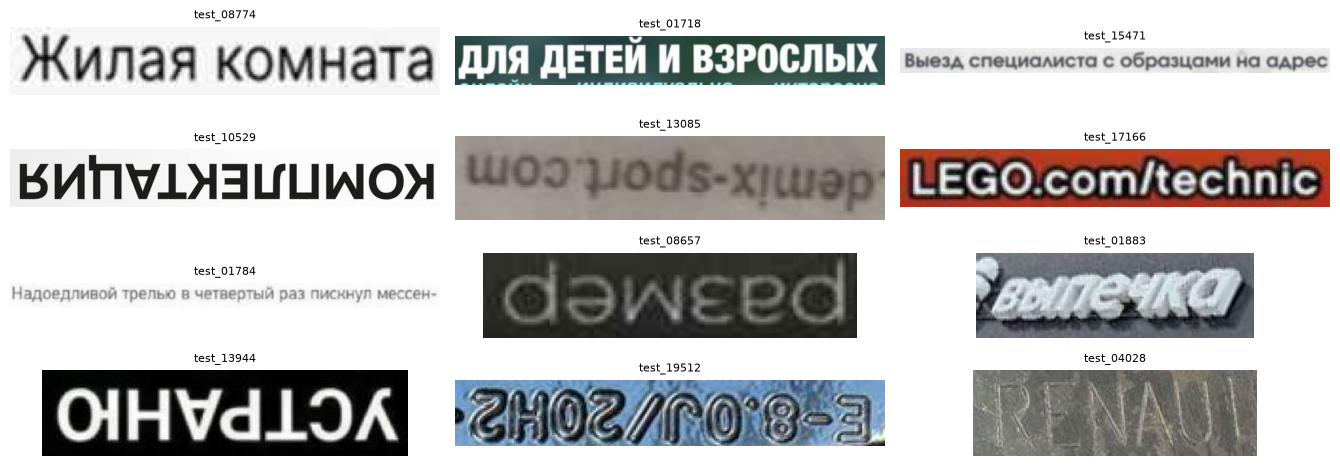

In [2]:
# Размеры кропов: хватит первых 3000, чтобы понять картину
sizes = pd.DataFrame([cv2.imread(str(TEST_IMAGES / f"{i}.png")).shape[:2] for i in test_ids[:3000]],
                     columns=["h", "w"])
sizes["w/h"] = sizes.w / sizes.h
print(sizes.describe().round(1).T[["mean", "25%", "50%", "75%", "max"]])
print("Вертикальных кропов (высота больше ширины):", int((sizes.h > sizes.w).sum()))

# И дюжина случайных кропов
rng = np.random.default_rng(SEED)
sample_ids = rng.choice(test_ids, 12, replace=False)
show_row([cv2.imread(str(TEST_IMAGES / f"{i}.png")) for i in sample_ids], list(sample_ids))

Что я для себя отметил:

* классов действительно два — 0° и 180°, вертикальных кропов практически нет;
* текст смешанный: кириллица и латиница;
* кропы вытянутые (ширина обычно в 3–8 раз больше высоты) — это пригодится при выборе входа для CNN;
* меток нет, так что первым делом нужна своя размеченная валидация.

## 2. Как проверять себя, если меток теста нет

### 2.1 Синтетика — основная валидация

Я написал небольшой генератор: он рисует текст системными шрифтами с кириллицей (их нашлось 203) и «портит»
картинку так, как это бывает в жизни — градиентный фон, неровные поля, как у детектора, небольшой наклон,
уменьшение, размытие, JPEG-артефакты. Текст — слова из объявлений, цены, телефоны, бренды.
Каждый кроп с вероятностью 0.5 переворачивается — вот и метка. Генерация детерминирована (seed 42).

Синтетическая валидация: 3000 кропов, из них перевёрнутых 48.4%


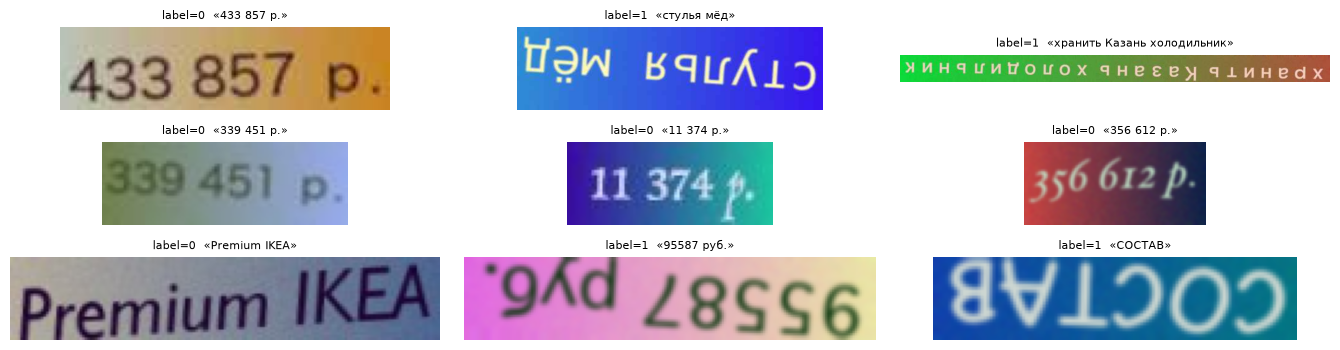

In [3]:
VAL_DIR = PROJECT / "data/synth_val"
# Картинки синтетики нужны, только если пересчитывать выходы моделей: калибровка учится на готовых
# выходах из features/. Если картинок нет, а пересчёт включён — генерируем их (шрифты берутся системные,
# поэтому на другой ОС набор кропов будет другим).
if RECOMPUTE_FEATURES and not (VAL_DIR / "images").exists():
    sh("make_synth_val.py", cwd=PROJECT / "scripts")

val = pd.read_csv(VAL_DIR / "labels.csv")
y_val = val.label.to_numpy()
print(f"Синтетическая валидация: {len(val)} кропов, из них перевёрнутых {y_val.mean():.1%}")

# label=1 — кроп перевёрнут
if (VAL_DIR / "images").exists():
    show_row([cv2.imread(str(VAL_DIR / "images" / f"{i}.png")) for i in val.image_id[:9]],
             [f"label={l}  «{t}»" for l, t in zip(val.label[:9], val.text[:9])])
else:
    print("(картинок нет в архиве — см. примеры в описании ниже; сгенерировать: scripts/make_synth_val.py)")

### 2.2 Реальные кропы — проверка «а не обманывает ли меня синтетика»

Синтетика всё-таки чище настоящих фото. Поэтому я дополнительно собрал реальные кропы из открытых датасетов
(в обучении CNN они **не** участвуют):

* 2000 кропов из валидации Union14M — реальные фото, в основном короткие английские слова;
* 1500 российских номеров машин;
* 1544 рукописных русских слова.

Половину из них я переворачиваю, как и в синтетике. Эта выборка оказалась заметно *сложнее* теста —
на ней я сравниваю методы, но калибровать по ней не стал (почему — в разделе 6.3).

Внешние данные скачиваются один раз (флаг `DOWNLOAD_EXTERNAL`) и упаковываются в `data/packed/`.

In [4]:
import urllib.request

# Откуда брать внешние данные (всё публичное, с HuggingFace)
HF = "https://huggingface.co/datasets"
DOWNLOADS = {
    "data/union14m_l/train-00000-of-00013.parquet": f"{HF}/Bekhouche/Union14M-L-STR/resolve/main/data/train-00000-of-00013.parquet",
    "data/union14m_l/train-00001-of-00013.parquet": f"{HF}/Bekhouche/Union14M-L-STR/resolve/main/data/train-00001-of-00013.parquet",
    "data/union14m_l/valid-00000-of-00003.parquet": f"{HF}/Bekhouche/Union14M-L-STR/resolve/main/data/valid-00000-of-00003.parquet",
    "data/ocr_cyrillic_printed6/data_6.zip": f"{HF}/DonkeySmall/OCR-Cyrillic-Printed-6/resolve/main/data_6.zip",
    "data/ocr_cyrillic_printed10/data_10.zip": f"{HF}/DonkeySmall/OCR-Cyrillic-Printed-10/resolve/main/data_10.zip",
    "data/russian_ocr_small/car_plate.parquet": f"{HF}/Foximaz/russian_ocr_small/resolve/main/car_plate/test-00000.parquet",
    "data/russian_ocr_small/handwriting.parquet": f"{HF}/Foximaz/russian_ocr_small/resolve/main/handwriting/test-00000.parquet",
}


def download(url, dst, attempts=10):
    """Скачивает файл с докачкой: на больших файлах HuggingFace соединение у меня иногда обрывалось."""
    dst.parent.mkdir(parents=True, exist_ok=True)
    for _ in range(attempts):
        done = dst.stat().st_size if dst.exists() else 0
        req = urllib.request.Request(url, headers={"Range": f"bytes={done}-"} if done else {})
        try:
            with urllib.request.urlopen(req, timeout=60) as r, open(dst, "ab" if done else "wb") as f:
                total = done + int(r.headers.get("Content-Length", 0))
                while chunk := r.read(1 << 20):
                    f.write(chunk)
            if dst.stat().st_size >= total:
                return
        except urllib.error.HTTPError as e:
            if e.code == 416: # файл уже скачан целиком
                return
            raise
        except OSError:
            pass # оборвалось — пробуем докачать
    raise RuntimeError(f"Не удалось скачать {url}")


if DOWNLOAD_EXTERNAL:
    for rel, url in DOWNLOADS.items():
        print("скачиваю", rel)
        download(url, PROJECT / rel)

# Реальная проверочная выборка: собираем, если есть внешние данные; иначе берём готовую из архива.
# Для самого submission.csv она не нужна — только для сравнения методов.
CALIB_DIR = PROJECT / "data/calib_val"
if not (CALIB_DIR / "labels.csv").exists() and (PROJECT / "data/russian_ocr_small/handwriting.parquet").exists():
    if not (PROJECT / "data/packed/union_valid.idx.npy").exists():
        sh("pack_data.py", cwd=PROJECT / "scripts")
    sh("make_calib_set.py", cwd=PROJECT / "scripts")

if (CALIB_DIR / "labels.csv").exists():
    calib = pd.read_csv(CALIB_DIR / "labels.csv")
    y_cal = calib.label.to_numpy()
    # (колонка font здесь хранит имя источника — формат общий с синтетикой)
    print(calib.groupby("font").label.agg(n="count", upside_down="mean").rename_axis("источник"))
    if (CALIB_DIR / "images").exists():
        for src in calib.font.unique():
            part = calib[calib.font == src].head(3)
            show_row([cv2.imread(str(CALIB_DIR / "images" / f"{i}.png")) for i in part.image_id],
                     [f"{src}  label={l}" for l in part.label])
else:
    calib, y_cal = None, None
    print("Реальной выборки нет — сравнение на реальных кропах будет пропущено (на submission.csv это не влияет)")

# на каких выборках можно заново прогонять модели: нужны сами картинки
SPLITS_TO_RUN = ["val", "test"] + (["calib"] if (CALIB_DIR / "images").exists() else [])

                n  upside_down
источник                      
ru_hand      1544     0.521373
ru_plates    1500     0.483333
union_valid  2000     0.503500


## 3. Готовые модели: как из OCR получить ориентацию

Первое, что я попробовал, — готовый классификатор ориентации строки из PaddleOCR. Он маленький и быстрый,
но на кириллице ошибается заметно чаще, чем хотелось бы: его учили в основном на китайском и английском.
Добавил к нему распознаватель кириллицы — он отлично знает, как выглядят русские буквы в правильной ориентации,
и именно он стал главным сигналом.

В итоге используются три готовые модели, и каждая запускается на кропе `x` **и** на `rot180(x)`:

* **`textline_x025`** — классификатор ориентации строки PaddleOCR (~0.25 млн параметров), даёт `P(180)`;
* **`rec_cyrillic_v5`** — распознаватель кириллицы PaddleOCR (~2 млн), даёт прочитанный текст и уверенность;
* **`rec_en_v5`** — распознаватель английского PaddleOCR (~2 млн): на латинских словах кириллический путается.

Давайте посмотрим на идею вживую — распознаватель читает кроп и его переворот:

In [5]:
from paddleocr import TextRecognition

demo_rec = TextRecognition(model_name="cyrillic_PP-OCRv5_mobile_rec", device="cpu")
demo = [cv2.imread(str(TEST_IMAGES / f"{i}.png")) for i in sample_ids[:6]]
pairs = demo + [cv2.rotate(img, cv2.ROTATE_180) for img in demo] # сначала кропы, потом их перевороты
res = list(demo_rec.predict(pairs, batch_size=12))

for k, i in enumerate(sample_ids[:6]):
    a, b = res[k], res[k + 6]
    # если перевёрнутый вариант читается увереннее — значит, исходный кроп стоит вверх ногами
    verdict = "скорее ПЕРЕВЁРНУТ" if b["rec_score"] > a["rec_score"] else "скорее нормальный"
    print(f"{i}:  x → «{a['rec_text']}» ({a['rec_score']:.2f})   "
          f"rot180(x) → «{b['rec_text']}» ({b['rec_score']:.2f})   ⇒ {verdict}")
del demo_rec

Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/mac/.paddlex/official_models/cyrillic_PP-OCRv5_mobile_rec`.


/Users/mac/Studying/avito_camp/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


test_08774:  x → «Жилая комната» (0.98)   rot180(x) → «ениож вециж» (0.64)   ⇒ скорее нормальный
test_01718:  x → «ДЛЯ ДЕТЕЙ И ВЗРОСЛЫХ» (0.98)   rot180(x) → «» (0.00)   ⇒ скорее нормальный
test_15471:  x → «Выезд специалиста с образцами на адрес» (0.96)   rot180(x) → «  » (0.51)   ⇒ скорее нормальный
test_10529:  x → «» (0.00)   rot180(x) → «КОМПЛЕКТАЦИЯ» (1.00)   ⇒ скорее ПЕРЕВЁРНУТ
test_13085:  x → «» (0.00)   rot180(x) → «demix-sport.com» (1.00)   ⇒ скорее ПЕРЕВЁРНУТ
test_17166:  x → «LEGO.com/technic» (1.00)   rot180(x) → «» (0.00)   ⇒ скорее нормальный


Теперь прогоняем все три модели по синтетике, реальной выборке и тесту. Это самая долгая часть
(~15–20 минут на распознаватель для 20 000 тестовых кропов на нескольких ядрах), поэтому результаты
лежат в `features/`. С флагом `RECOMPUTE_FEATURES` всё пересчитывается заново.

In [6]:
READY_MADE = ["textline_x025", "rec_cyrillic_v5", "rec_en_v5"]
for split in ["val", "calib", "test"]:
    for method in READY_MADE:
        can_run = split in SPLITS_TO_RUN
        if can_run and (RECOMPUTE_FEATURES or not feature_exists(split, method)):
            sh("compute_features.py", "--method", method, "--split", split, "--workers", WORKERS,
               cwd=PROJECT / "scripts")
        elif feature_exists(split, method):
            print(f"{split}_{method}: уже посчитан, беру с диска")
        else:
            print(f"{split}_{method}: нет ни картинок, ни готовых выходов — пропускаю")

# Так выглядят выходы распознавателя: уверенность (s_*), длина и сам текст для кропа и его переворота
pd.read_csv(PROJECT / "features/test_rec_cyrillic_v5.csv", keep_default_na=False).head()

val_textline_x025: уже посчитан, беру с диска
val_rec_cyrillic_v5: уже посчитан, беру с диска
val_rec_en_v5: уже посчитан, беру с диска
calib_textline_x025: уже посчитан, беру с диска
calib_rec_cyrillic_v5: уже посчитан, беру с диска
calib_rec_en_v5: уже посчитан, беру с диска
test_textline_x025: уже посчитан, беру с диска
test_rec_cyrillic_v5: уже посчитан, беру с диска
test_rec_en_v5: уже посчитан, беру с диска


,image_id,s_x,s_rot,len_x,len_rot,text_x,text_rot
0,test_00000,0.932139,0.000000,10,0,KinG styla,
1,test_00001,0.452310,0.996477,1,11,S,DES PARFUMS
2,test_00002,0.000000,0.831736,0,8,,ОТКАТНЫЕ
3,test_00003,0.980706,0.519608,12,10,MICHAEL KORS,S60X13YHDN
4,test_00004,0.336763,0.718414,6,11,иoхнеW,МурманХобби


## 4. Своя CNN

Распознаватель бессилен там, где текст не читается ни в одну сторону: декоративные шрифты, логотипы, рукопись.
Для таких кропов обучаем маленькую сетку, которая смотрит прямо на картинку: 4 conv-блока 32→64→128→256
с BatchNorm, 390 тыс. параметров, вход 32×256, 10 эпох по 200 тыс. кропов.

Детали, которые оказались важны:

* сеть выдаёт логит, учим с `BCEWithLogitsLoss`;
* в конце усредняю признаки только по ширине, оставляя несколько «строк» по высоте: для ориентации важно,
  где верх, а где низ, глобальный пулинг это стирает;
* **антисимметричная голова** `logit(x) = g(x) − g(rot180(x))` — отсюда `p(rot180(x)) = 1 − p(x)` по построению;
* кроп масштабируется по высоте и дополняется до нужной ширины **по центру**: тогда переворот тензора совпадает
  с предобработкой перевёрнутого кропа.

**Данные — только внешние**, все кропы там стоят правильно, метку делаю сам: на лету переворачиваю половину.
За эпоху 30% OCR-Cyrillic-Printed-6, 30% Printed-10 (кириллические шрифты) и 40% Union14M-L (реальные фото,
без «сложных» и вертикальных кропов — там часто повёрнутый на 90° текст).

**Аугментации** любые, кроме меняющих ориентацию: неточные поля, наклон ±5°, перекраска, яркость, инверсия, шум,
размытие, JPEG. Горизонтальное отражение не использую — зеркальный текст это не «перевёрнутый».
Свою синтетику в обучение не добавлял, иначе валидация на ней стала бы нечестной.

cnn_v1 {'params': 389921, 'checkpoint_mb': 1.5, 'cpu1_bs1_ms_per_crop': 9.064, 'cpu1_bs64_ms_per_crop': 16.584}


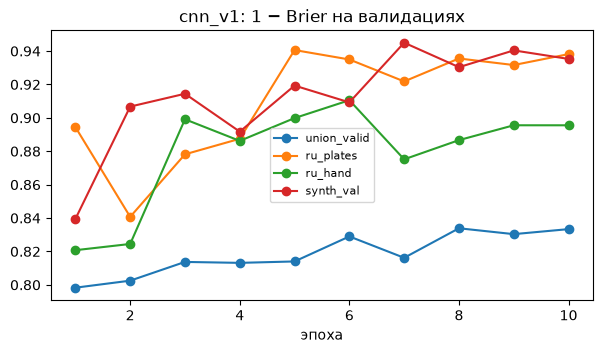

In [7]:
# Если весов нет — обучаем (нужны внешние данные, см. DOWNLOAD_EXTERNAL)
if RETRAIN_CNN or not (PROJECT / f"checkpoints/{CNN_TAG}.pt").exists():
    sh("pack_data.py", cwd=PROJECT / "scripts") # упакует скачанные датасеты, если ещё не
    sh("train.py", "--tag", CNN_TAG, *CNN_TRAIN_ARGS, cwd=PROJECT / "scripts")
if RETRAIN_CNN or RECOMPUTE_FEATURES or not feature_exists("test", CNN_TAG):
    sh("predict.py", "--tag", CNN_TAG, "--splits", *SPLITS_TO_RUN, cwd=PROJECT / "scripts")

speed_cnn = json.loads((PROJECT / f"features/speed_{CNN_TAG}.json").read_text())
print(CNN_TAG, speed_cnn)

# Кривые обучения: качество «голой» сети (без калибровки) на валидациях после каждой эпохи
hist = pd.read_csv(PROJECT / f"checkpoints/{CNN_TAG}_history.csv") # лог обучения по эпохам
fig, ax = plt.subplots(figsize=(7, 3.5))
for col in [c for c in hist.columns if c.endswith("_brier") and c != "mean_val_brier"]:
    ax.plot(hist.epoch, 1 - hist[col], marker="o", label=col.replace("_brier", ""))
ax.set_title(f"{CNN_TAG}: 1 − Brier на валидациях"); ax.set_xlabel("эпоха"); ax.legend(fontsize=8)
plt.show()

Сеть сама по себе слабее распознавателя, но ошибается на других кропах — потому и полезна в ансамбле.

## 5. Как из выходов моделей получается вероятность

Для каждой модели я считаю разность «перевёрнутый вариант минус исходный»:

* для классификаторов (`textline`, CNN): `logit P(180|x) − logit P(180|rot180(x))`;
* для распознавателей: разность уверенности, разность её логитов и разность `log(1 + длина текста)`.

У всех этих признаков есть приятное свойство — **антисимметричность**: для перевёрнутого кропа они ровно
с обратным знаком. Если поставить сверху логистическую регрессию **без свободного члена**, то автоматически
получится `p(rot180(x)) = 1 − p(x)` — как и должно быть по смыслу задачи. По той же причине признаки
масштабируются без центрирования: сдвиг сломал бы симметрию.

Регрессия обучается на синтетике. Качество везде считаю **out-of-fold**:
каждое предсказание сделано моделью, которая этот кроп не видела.

In [8]:
# Вот как выглядят признаки (здесь — полный набор, для точного варианта)
X_example = load_features(FEAT_DIRS, "val", VARIANTS["accurate"], val.image_id.tolist())
X_example.head()

,cnn_v1__dlogit,textline_x025__dlogit,rec_cyrillic_v5__ds,rec_cyrillic_v5__dlogit,rec_cyrillic_v5__dlen,rec_en_v5__ds,rec_en_v5__dlogit,rec_en_v5__dlen
0,-14.774271,-18.420481,-0.966569,-12.574508,-2.397895,-0.301886,-2.338191,-0.451985
1,18.420481,17.889827,0.319228,3.016262,2.397895,0.343509,1.739693,-1.386294
2,3.322796,-2.159724,0.443452,3.898646,0.160343,0.634882,3.003280,0.847298
3,2.267040,-16.366116,-0.963163,-12.473957,-2.397895,-0.536091,-4.848229,-0.200671
4,-8.333239,-17.544756,-0.453576,-2.542336,-2.302585,-0.447127,-2.567606,-0.510826


## 6. Сравниваем подходы

### 6.1 Каждая модель по отдельности

Сюда я добавил и то, что пробовал, но не взял: классификатор ориентации из docTR, EasyOCR, ещё два распознавателя
PaddleOCR (`eslav_v5`, `cyrillic_v3`). На реальной выборке выходы считал не для всех — у кого не считал,
в таблице прочерки.

In [9]:
def evaluate(methods, seeds=(42, 1, 2)):
    """Качество набора моделей: out-of-fold на синтетике (среднее по нескольким разбиениям)
    и перенос на реальные кропы (калибратор обучен на всей синтетике)."""
    X_val = load_features(FEAT_DIRS, "val", methods, val.image_id.tolist())
    oofs = [metrics(oof_predict(X_val, y_val, seed=s), y_val) for s in seeds]
    res = {"synth": np.mean([o["1-brier"] for o in oofs]), "synth acc": np.mean([o["acc"] for o in oofs])}
    if calib is not None and all(feature_exists("calib", m.split(":")[0]) for m in methods):
        model = make_model().fit(X_val, y_val)
        p = model.predict_proba(load_features(FEAT_DIRS, "calib", methods, calib.image_id.tolist()))[:, 1]
        res["real (все)"] = metrics(p, y_cal)["1-brier"]
        for src in calib.font.unique():
            m = (calib.font == src).to_numpy()
            res[f"real: {src}"] = metrics(p[m], y_cal[m])["1-brier"]
    return res


SINGLE = ["textline_x025", "doctr_crop", "easyocr_ru", "rec_cyrillic_v3", "rec_eslav_v5",
          "rec_cyrillic_v5", "rec_en_v5", CNN_TAG]
single_table = pd.DataFrame({m: evaluate([m]) for m in SINGLE if feature_exists("val", m)}).T
single_table.sort_values("synth", ascending=False).round(4)

,synth,synth acc,real (все),real: union_valid,real: ru_plates,real: ru_hand
rec_cyrillic_v5,0.9915,0.9896,0.8771,0.8294,0.9939,0.8255
rec_eslav_v5,0.9893,0.9870,0.8683,0.8358,0.9931,0.7892
rec_en_v5,0.9590,0.9568,0.9048,0.8451,0.9916,0.8980
textline_x025,0.9463,0.9263,0.9104,0.8149,0.9987,0.9483
cnn_v1,0.9362,0.9100,0.8847,0.8357,0.9401,0.8944
easyocr_ru,0.8971,0.8486,NaN,NaN,NaN,NaN
rec_cyrillic_v3,0.8805,0.8328,NaN,NaN,NaN,NaN
doctr_crop,0.8605,0.7787,NaN,NaN,NaN,NaN


Что я вижу в таблице:

* лучший одиночный метод — **распознаватель кириллицы**, 0.992 на синтетике;
* на реальных латинских словах из Union14M проседают все: короткие размытые «the» и «to» трудно сориентировать
  даже человеку;
* номера машин почти идеально ориентирует даже `textline`;
* CNN слабее распознавателя, зато быстрее в 130 раз — именно поэтому она хорошо работает первой ступенью каскада.

### 6.2 Ансамбли

Дальше добавлял модели по одной и смотрел, что меняется.

In [10]:
ENSEMBLES = {
    "fast: textline + rec_cyr (LB 0.99228)": VARIANTS["fast"],
    "+ rec_en": ["textline_x025", "rec_cyrillic_v5", "rec_en_v5"],
    "+ cnn": [CNN_TAG, "textline_x025", "rec_cyrillic_v5"],
    "+ языковая модель по тексту": ["textline_x025", "rec_cyrillic_v5:lm", "rec_en_v5:lm"],
    "+ eslav_v5": ["textline_x025", "rec_cyrillic_v5", "rec_eslav_v5"],
    "accurate: cnn + textline + rec_cyr + rec_en (LB 0.99422)": VARIANTS["accurate"],
}
# (":lm" — дополнительный признак языковой модели по распознанному тексту, см. src/textlm.py)
ens_table = pd.DataFrame({name: evaluate(ms, seeds=(42, 1, 2, 3, 4)) for name, ms in ENSEMBLES.items()
                          if all(feature_exists("val", m.split(":")[0]) for m in ms)}).T
ens_table.round(4)

,synth,synth acc,real (все),real: union_valid,real: ru_plates,real: ru_hand
fast: textline + rec_cyr (LB 0.99228),0.9931,0.9923,0.9083,0.8375,0.9987,0.9121
+ rec_en,0.9938,0.9920,0.9180,0.8484,0.9989,0.9295
+ cnn,0.9938,0.9926,0.9202,0.8523,0.9971,0.9333
+ языковая модель по тексту,0.9937,0.9919,0.9149,0.8478,0.9986,0.9206
+ eslav_v5,0.9931,0.9911,0.9080,0.8454,0.9986,0.9010
accurate: cnn + textline + rec_cyr + rec_en (LB 0.99422),0.9944,0.9935,0.9281,0.8618,0.9974,0.9466


Выводы:

* **английский распознаватель и CNN** дают по чуть-чуть каждый, вместе — лучший результат (0.99422 против 0.99228).
  Минус: на всех кропах это удваивает время, решение — каскад (6.4);
* пробовал предобученный MobileNetV3-small вместо своей CNN и обе сети вместе: на синтетике чуть выше,
  на реальных кропах не лучше, параметров больше. Оставил свою;
* **языковая модель** по распознанному тексту (символьные 4-граммы) прироста не дала: это уже есть в уверенности
  распознавателя;
* второй кириллический распознаватель (`eslav_v5`) почти ничего не добавляет, а это ещё 2 млн параметров.

### 6.3 Что ещё пробовал и почему не взял

Две проверки про калибратор — на полном наборе признаков, где у сложных методов больше всего шансов.

In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold


class AntisymmetricGBM:
    """Градиентный бустинг с той же симметрией.

    Учим на исходных примерах и на их «зеркалах» (−X, 1 − y), а ответ усредняем: p = (g(X) + 1 − g(−X)) / 2.
    """

    def __init__(self):
        self.model = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200,
                                                    l2_regularization=1.0, random_state=SEED)

    def fit(self, X, y):
        X = np.asarray(X)
        self.model.fit(np.vstack([X, -X]), np.concatenate([y, 1 - y]))
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        p = (self.model.predict_proba(X)[:, 1] + 1 - self.model.predict_proba(-X)[:, 1]) / 2
        return np.stack([1 - p, p], axis=1)


X_val = load_features(FEAT_DIRS, "val", VARIANTS["accurate"], val.image_id.tolist())
has_real = calib is not None and all(feature_exists("calib", m) for m in VARIANTS["accurate"])
X_cal = load_features(FEAT_DIRS, "calib", VARIANTS["accurate"], calib.image_id.tolist()) if has_real else None
real_score = lambda p: metrics(p, y_cal)["1-brier"] if has_real else np.nan

# база для сравнения — обычная логистическая регрессия на синтетике
lr_oof = oof_predict(X_val, y_val, seed=SEED)
lr_real = make_model().fit(X_val, y_val).predict_proba(X_cal)[:, 1] if has_real else None
rows = [{"вариант": "логистическая регрессия (оставил её)", "synth": metrics(lr_oof, y_val)["1-brier"],
         "real": real_score(lr_real)}]

# 1) бустинг вместо логистической регрессии
gbm_oof = np.zeros(len(y_val))
for tr, va in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X_val, y_val):
    gbm_oof[va] = AntisymmetricGBM().fit(X_val.iloc[tr], y_val[tr]).predict_proba(X_val.iloc[va])[:, 1]
gbm_real = AntisymmetricGBM().fit(X_val, y_val).predict_proba(X_cal)[:, 1] if has_real else None
rows.append({"вариант": "антисимметричный градиентный бустинг", "synth": metrics(gbm_oof, y_val)["1-brier"],
             "real": real_score(gbm_real)})

# 2) калибровка на синтетике и реальных кропах вместе (качество считаю отдельно по частям)
if has_real:
    X_both = pd.concat([X_val, X_cal], ignore_index=True)
    joint_oof = oof_predict(X_both, np.concatenate([y_val, y_cal]), seed=SEED)
    rows.append({"вариант": "калибровка на синтетике + реальных",
                 "synth": metrics(joint_oof[:len(y_val)], y_val)["1-brier"],
                 "real": metrics(joint_oof[len(y_val):], y_cal)["1-brier"]})

pd.DataFrame(rows).set_index("вариант").round(4)

,synth,real
вариант,,
логистическая регрессия (оставил её),0.9944,0.9281
антисимметричный градиентный бустинг,0.9945,0.9198
калибровка на синтетике + реальных,0.9886,0.9411


* **Бустинг**: на синтетике то же самое, на реальные кропы переносится хуже. Признаков мало, нелинейности взяться
  неоткуда — проще лучше.
* **Калибровка вместе с реальными кропами**: та выборка сложнее теста, модель становится осторожнее и теряет
  качество на синтетике, которая к тесту ближе.

Ещё пробовал: только `textline` с симметричным TTA и EM-оценкой доли перевёрнутых (их в тесте ~50%, поправка
ничего не меняет), `textline x1_0` вместо маленькой (хуже), docTR, EasyOCR, `cyrillic_v3` (слабее — видно
в таблице 6.1). Псевдо-метки на тесте не использовал: серая зона правил, и в проде так не сделать.

### 6.4 Скорость: каскад

Точный вариант вдвое дороже быстрого. Но зачем звать дорогие модели, если быстрая часть и так уверена? Каскад:

1. всегда считаем `fast` (textline + распознаватель кириллицы);
2. уверен (`p < 0.05` или `p > 0.95`) — это ответ;
3. не уверен — дозапускаем английский распознаватель и CNN, берём ответ `accurate`.

Порог подбирал на валидации, ниже видно качество и среднее время.

In [12]:
# Out-of-fold предсказания обоих вариантов на синтетике
fast_oof = oof_predict(load_features(FEAT_DIRS, "val", VARIANTS["fast"], val.image_id.tolist()), y_val, seed=SEED)
acc_oof = oof_predict(load_features(FEAT_DIRS, "val", VARIANTS["accurate"], val.image_id.tolist()), y_val, seed=SEED)

# На реальных кропах и тесте — калибраторы, обученные на всей синтетике
real_p, test_p = {}, {}
for v, ms in VARIANTS.items():
    model = make_model().fit(load_features(FEAT_DIRS, "val", ms, val.image_id.tolist()), y_val)
    if has_real:
        real_p[v] = model.predict_proba(load_features(FEAT_DIRS, "calib", ms, calib.image_id.tolist()))[:, 1]
    test_p[v] = model.predict_proba(load_features(FEAT_DIRS, "test", ms, test_ids))[:, 1]

# Время моделей (замерено на Apple M5, один поток CPU). Беру минимальный замер на тесте:
# часть прогонов шла параллельно с другими расчётами
timings = pd.read_csv(PROJECT / "features/timings.csv")
paddle_ms = timings[timings.split == "test"].groupby("method").ms_per_pass_single_core.min()
fast_ms = 2 * (paddle_ms["textline_x025"] + paddle_ms["rec_cyrillic_v5"]) # ×2: кроп и его переворот
extra_ms = 2 * paddle_ms["rec_en_v5"] + speed_cnn["cpu1_bs1_ms_per_crop"] # вторая ступень

rows = []
for t in [0.5, 0.8, 0.9, 0.95, 0.98, 0.99, 0.999, 1.01]:
    p_syn, _ = cascade(fast_oof, acc_oof, t)
    p_real = cascade(real_p["fast"], real_p["accurate"], t)[0] if has_real else None
    _, share_test = cascade(test_p["fast"], test_p["accurate"], t)
    rows.append({"порог": t, "1 − Brier synth": metrics(p_syn, y_val)["1-brier"],
                 "1 − Brier real": real_score(p_real),
                 "доля теста во 2-ю ступень": share_test,
                 "мс на кроп (среднее)": fast_ms + share_test * extra_ms})
cascade_table = pd.DataFrame(rows)
cascade_table.round(4)

,порог,1 − Brier synth,1 − Brier real,доля теста во 2-ю ступень,мс на кроп (среднее)
0,0.500,0.9932,0.9083,0.0000,324.7940
1,0.800,0.9946,0.9213,0.0235,333.3873
2,0.900,0.9944,0.9252,0.0404,339.5854
3,0.950,0.9945,0.9263,0.0609,347.0634
4,0.980,0.9944,0.9272,0.0951,359.5694
5,0.990,0.9944,0.9276,0.1258,370.7773
6,0.999,0.9944,0.9280,0.2578,419.0642
7,1.010,0.9944,0.9281,1.0000,690.4660


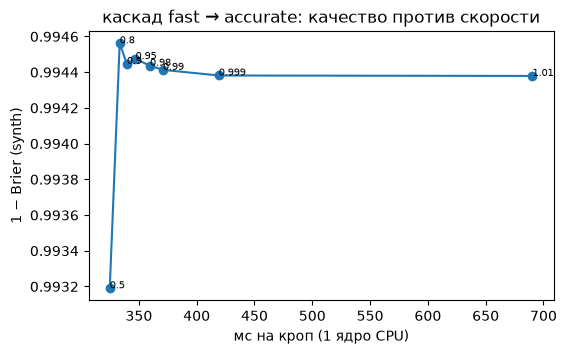

In [13]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(cascade_table["мс на кроп (среднее)"], cascade_table["1 − Brier synth"], marker="o")
for _, r in cascade_table.iterrows():
    ax.annotate(str(r["порог"]), (r["мс на кроп (среднее)"], r["1 − Brier synth"]), fontsize=7)
ax.set_xlabel("мс на кроп (1 ядро CPU)"); ax.set_ylabel("1 − Brier (synth)")
ax.set_title("каскад fast → accurate: качество против скорости")
plt.show()

Уже при пороге 0.9–0.95 каскад догоняет точный вариант, а во вторую ступень уходит всего 4–6% тестовых кропов.
Взял **0.95**: на реальных кропах надёжнее, чем 0.9, а стоит на пару миллисекунд дороже.

## 7. Итоговое решение

| | `fast` | `accurate` | **`cascade`** |
|---|---|---|---|
| модели | textline + распознаватель кириллицы | + распознаватель английского + CNN | `fast`, для ~6% кропов — `accurate` |
| 1 − Brier | 0.99228 | 0.99422 | **0.99422** |
| параметров | ~2.25 млн | ~4.6 млн | ~4.6 млн |
| мс на кроп, 1 ядро CPU | ~325 | ~684 | **~347** |

`accurate` ошибается на четверть меньше `fast`, но каждый кроп вдвое дороже, а в проде это сотни миллионов боксов
в день. Каскад снимает выбор: качество точного варианта, цена почти быстрого. Платим памятью — держать нужно все
модели. Если критичен размер, есть `FINAL_VARIANT = "fast"`.

Ниже считаются все три варианта, для каждого калибратор обучается на всей синтетике и применяется к тесту.
Итог сохраняется в **`submission.csv`**.

In [14]:
predictions, calibrators = {}, {}
for variant, methods in VARIANTS.items():
    X_v = load_features(FEAT_DIRS, "val", methods, val.image_id.tolist())
    calibrators[variant] = make_model().fit(X_v, y_val)
    predictions[variant] = calibrators[variant].predict_proba(load_features(FEAT_DIRS, "test", methods, test_ids))[:, 1]

# Каскад: ответ fast там, где он уверен, и ответ accurate на остальных кропах
predictions["cascade"], cascade_share = cascade(predictions["fast"], predictions["accurate"], CASCADE_THRESHOLD)
print(f"Каскад: во вторую ступень ушло {cascade_share:.1%} тестовых кропов "
      f"(в среднем ~{fast_ms + cascade_share * extra_ms:.0f} мс на кроп)")

p_test = predictions[FINAL_VARIANT]

# Какие признаки важнее всего. В каскаде работают оба калибратора — покажу оба
show_variant = ["fast", "accurate"] if FINAL_VARIANT == "cascade" else [FINAL_VARIANT]
for variant in show_variant:
    calibrator = calibrators[variant]
    feature_names = load_features(FEAT_DIRS, "val", VARIANTS[variant], val.image_id.tolist()[:1]).columns
    # делим на масштаб, чтобы веса относились к признакам в исходных единицах
    coef = pd.Series(calibrator[-1].coef_[0] / calibrator[0].scale_, index=feature_names, name="вес признака")
    print()
    print(f"Веса признаков калибратора {variant}:")
    print(coef.round(3).to_string())

Каскад: во вторую ступень ушло 6.1% тестовых кропов (в среднем ~347 мс на кроп)

Веса признаков калибратора fast:
textline_x025__dlogit      0.180
rec_cyrillic_v5__ds        6.664
rec_cyrillic_v5__dlogit    0.330
rec_cyrillic_v5__dlen      0.935

Веса признаков калибратора accurate:
cnn_v1__dlogit             0.160
textline_x025__dlogit      0.126
rec_cyrillic_v5__ds        5.837
rec_cyrillic_v5__dlogit    0.174
rec_cyrillic_v5__dlen      0.439
rec_en_v5__ds              2.291
rec_en_v5__dlogit          0.180
rec_en_v5__dlen            0.924


Самый большой вес — у разности уверенности распознавателя кириллицы, это главный «голос». `textline` поправляет его
там, где он сомневается; в точном варианте то же делают английский распознаватель и CNN.

Осталось проверить формат и сохранить файл:

Сохранено: /Users/mac/Studying/avito_camp/submission.csv


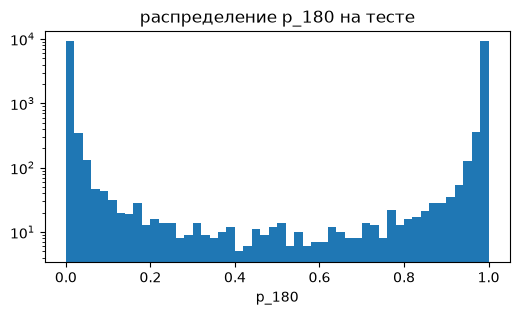

In [15]:
submission = pd.DataFrame({"image_id": test_ids, "p_180": p_test})

# Проверки формата: строк столько же, сколько кропов на входе, и вероятности в [0, 1]
assert list(submission.columns) == ["image_id", "p_180"]
assert len(submission) == len(test_ids)
assert submission.p_180.between(0, 1).all() and submission.p_180.notna().all()
if SAMPLE.exists(): # если есть файл-пример, сверяем id и их порядок
    sample = pd.read_csv(SAMPLE)
    assert (submission.image_id == sample.image_id.astype(str)).all()

submission.to_csv(SUBMISSION, index=False)
print(f"Сохранено: {SUBMISSION}")

plt.figure(figsize=(6, 3))
plt.hist(p_test, bins=50, log=True)
plt.title("распределение p_180 на тесте"); plt.xlabel("p_180")
plt.show()

Распределение почти целиком у краёв — модель уверена на подавляющем большинстве кропов.

Напоследок кропы, где быстрый и точный варианты разошлись: видно, что случаи и правда спорные.

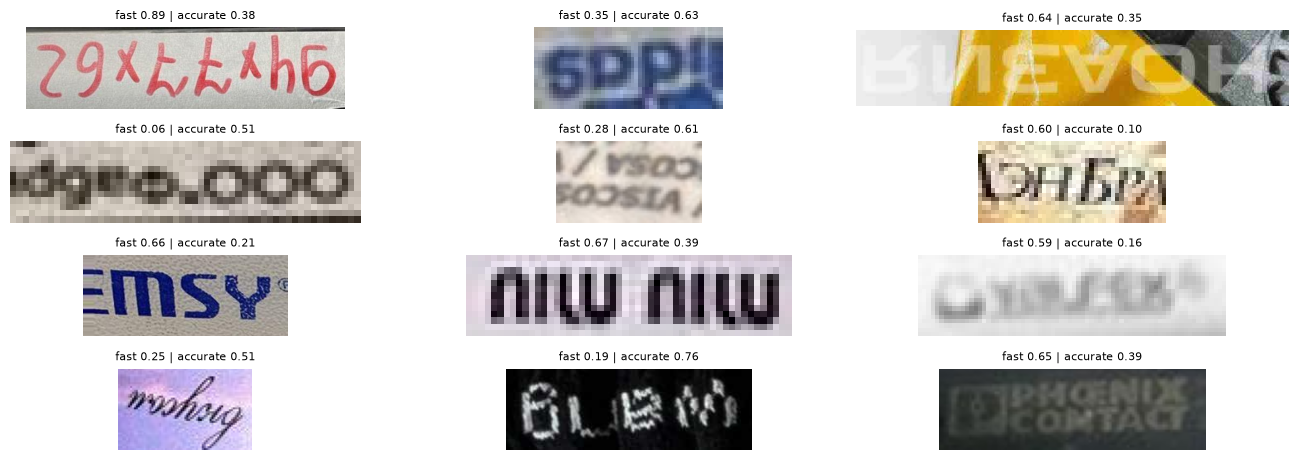

In [16]:
# кропы, где быстрый и точный варианты выбрали разный класс
changed = (predictions["fast"] > 0.5) != (predictions["accurate"] > 0.5)
idx = np.where(changed)[0]
pick = np.random.default_rng(SEED).choice(idx, size=min(12, len(idx)), replace=False)
show_row([cv2.imread(str(TEST_IMAGES / f"{test_ids[i]}.png")) for i in pick],
         [f"fast {predictions['fast'][i]:.2f} | accurate {predictions['accurate'][i]:.2f}" for i in pick])

## 8. Размер и скорость

Считаю по каждой модели: параметры и время на кроп с учётом двух прогонов (`x` и `rot180(x)`).

In [17]:
MS = "мс на кроп (1 ядро CPU, x и rot180)"
size_table = pd.DataFrame([
    {"модель": "textline_x025", "параметров, млн": 0.25, MS: 2 * paddle_ms["textline_x025"]},
    {"модель": "rec_cyrillic_v5", "параметров, млн": 2.0, MS: 2 * paddle_ms["rec_cyrillic_v5"]},
    {"модель": "rec_en_v5", "параметров, млн": 2.0, MS: 2 * paddle_ms["rec_en_v5"]},
    {"модель": CNN_TAG, "параметров, млн": speed_cnn["params"] / 1e6,
     MS: speed_cnn["cpu1_bs1_ms_per_crop"]},
    {"модель": "логистическая регрессия", "параметров, млн": X_val.shape[1] / 1e6, MS: 0.0},
]).set_index("модель")
for variant, methods in VARIANTS.items():
    size_table.loc[f"ИТОГО {variant}"] = size_table.loc[methods + ["логистическая регрессия"]].sum()
size_table.loc["ИТОГО cascade"] = [size_table.loc["ИТОГО accurate"].iloc[0], fast_ms + cascade_share * extra_ms]
size_table.round(3)

,"параметров, млн","мс на кроп (1 ядро CPU, x и rot180)"
модель,,
textline_x025,0.25,11.750
rec_cyrillic_v5,2.00,313.044
rec_en_v5,2.00,356.608
cnn_v1,0.39,9.064
логистическая регрессия,0.00,0.000
ИТОГО fast,2.25,324.794
ИТОГО accurate,4.64,690.466
ИТОГО cascade,4.64,347.063


Параметры PaddleOCR оценил по размеру файла весов (float32), время — среднее по реальному тесту, у CNN вход
фиксированный. Английский распознаватель мерил, когда параллельно работал кириллический, так что это оценка сверху.

Почти всё время уходит на распознаватели: второй на всех кропах удвоил бы стоимость, в каскаде он работает только
на ~6%.

## 9. Что в итоге

* Лучший сигнал ориентации — **уверенность OCR-распознавателя** на кропе и его перевороте; готовый классификатор
  ориентации кириллицу знает плохо.
* **Симметрия задачи** зашита в признаки, калибратор и CNN, вероятности откалиброваны под Brier.
* **Своя CNN** (обучена только на открытых данных) и **английский распознаватель** подняли 1 − Brier
  с 0.99228 до 0.99422, а **каскад** сохранил это качество за ~347 мс на кроп вместо ~684.
* **Синтетическая валидация** предсказала итоговую метрику с точностью до 0.001, тестовые картинки в обучении
  не участвовали.

**Что сделал бы дальше:** добавил бы в обучение CNN реальные русские фото (RusTitW) и декоративные шрифты,
а затем дистиллировал бы весь ансамбль в одну компактную сеть — это путь к единицам миллисекунд на кроп.

Спасибо, что дочитали! 🙂